In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Load Master Data

In [ ]:
# --- INSERT YOUR DIRECTORY PATH HERE ---
# (Remember to use forward slashes '/' on your Mac)
BASE_PATH = "YOUR_DIRECTORY_PATH_HERE"

print("=" * 60)
print("  LOADING MASTER DATA")
print("=" * 60)
train = pd.read_parquet('train_master.parquet')
test  = pd.read_parquet('test_master.parquet')
print(f"Train shape: {train.shape} | Test shape: {test.shape}")

  LOADING MASTER DATA
Train shape: (3000888, 16) | Test shape: (28512, 11)


## Step 1 — Target Transformation (log1p)
`log1p` giảm skewness của sales, giúp model hội tụ tốt hơn.

In [ ]:
print("[1/10] Target Transformation (log1p)...")
train['sales_log'] = np.log1p(train['sales'])

[1/10] Target Transformation (log1p)...


## Step 2 — Concat Train + Test để Engineer đồng bộ
Phải concat trước để lag/rolling không bị đứt giữa train-test.

In [ ]:
test['sales']     = np.nan
test['sales_log'] = np.nan
train['is_test']  = 0
test['is_test']   = 1
df = pd.concat([train, test], ignore_index=True)

# Bắt buộc sort theo chuỗi thời gian trước khi tính lag/rolling
df = df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
print(f"Combined shape: {df.shape}")

Combined shape: (3029400, 19)


## Step 3 — Rename Ambiguous Columns
`type_x` = store type, `type_y` = holiday type

In [ ]:
rename_map = {}
if 'type_x' in df.columns: rename_map['type_x'] = 'store_type'
if 'type_y' in df.columns: rename_map['type_y'] = 'holiday_type'
if rename_map:
    df = df.rename(columns=rename_map)
print(f"Renamed: {rename_map}")

Renamed: {'type_x': 'store_type', 'type_y': 'holiday_type'}


## Step 4 — Time Features (17 features)
Tất cả các đặc trưng thời gian từ cột `date`, bao gồm cyclical encoding.

In [ ]:
print("[2/10] Generating Time Features (17)...")
df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['day']        = df['date'].dt.day
df['dayofweek']  = df['date'].dt.dayofweek         # 0=Mon, 6=Sun
df['dayofyear']  = df['date'].dt.dayofyear
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter']    = df['date'].dt.quarter

df['is_weekend']     = df['dayofweek'].isin([5, 6]).astype(int)
# FIX: so sánh từng hàng thay vì .isin(Series)
df['is_payday']      = ((df['day'] == 15) | (df['day'] == df['date'].dt.days_in_month)).astype(int)
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end']   = df['date'].dt.is_month_end.astype(int)
df['is_year_start']  = df['date'].dt.is_year_start.astype(int)
df['is_year_end']    = df['date'].dt.is_year_end.astype(int)

# Cyclical encoding: giúp model hiểu tháng 12 gần tháng 1, thứ 7 gần thứ 2
df['month_sin']     = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']     = np.cos(2 * np.pi * df['month'] / 12)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

print("✅ Time features created.")

[2/10] Generating Time Features (17)...
✅ Time features created.


## Step 5 — Holiday Features (5 features)
Tạo flag boolean **trước** khi label encode `locale` / `holiday_type`.

In [ ]:
print("[3/10] Engineering Holiday Features (5)...")
if 'holiday_type' in df.columns:
    df['is_holiday'] = (
        df['holiday_type'].notna() &
        (df['holiday_type'].astype(str) != 'nan') &
        (df['holiday_type'].astype(str) != 'Unknown')
    ).astype(int)
else:
    df['is_holiday'] = 0

if 'locale' in df.columns:
    df['is_national_holiday'] = (df['locale'].astype(str) == 'National').astype(int)
    df['is_regional_holiday'] = (df['locale'].astype(str) == 'Regional').astype(int)
    df['is_local_holiday']    = (df['locale'].astype(str) == 'Local').astype(int)
else:
    df['is_national_holiday'] = 0
    df['is_regional_holiday'] = 0
    df['is_local_holiday']    = 0

df['is_transferred'] = df['transferred'].astype(int) if 'transferred' in df.columns else 0
print("✅ Holiday features created.")

[3/10] Engineering Holiday Features (5)...
✅ Holiday features created.


## Step 6 — Oil Features (6 features)
Giá dầu ảnh hưởng mạnh đến nền kinh tế Ecuador.

In [ ]:
print("[4/10] Engineering Oil Features (6)...")
oil_daily = df[['date', 'dcoilwtico']].drop_duplicates().sort_values('date').copy()

oil_daily['oil_change_7d']  = oil_daily['dcoilwtico'] - oil_daily['dcoilwtico'].shift(7)
oil_daily['oil_change_30d'] = oil_daily['dcoilwtico'] - oil_daily['dcoilwtico'].shift(30)
for w in [7, 14, 30]:
    oil_daily[f'oil_ma_{w}'] = oil_daily['dcoilwtico'].rolling(w, min_periods=1).mean()

oil_new_cols = ['oil_change_7d', 'oil_change_30d', 'oil_ma_7', 'oil_ma_14', 'oil_ma_30']
# FIX: Guard tránh duplicate column khi chạy lại cell trong notebook
for col in oil_new_cols:
    if col in df.columns:
        df = df.drop(columns=[col])
df = df.merge(oil_daily[['date'] + oil_new_cols], on='date', how='left')
print("✅ Oil features created.")

[4/10] Engineering Oil Features (6)...
✅ Oil features created.


## Step 7 — Earthquake Recovery Flag (1 feature)
Trận động đất 16/4/2016 ảnh hưởng ~2 tuần sau đó.

In [ ]:
print("[5/10] Adding Earthquake Recovery Flag (1)...")
earthquake_date = pd.to_datetime('2016-04-16')
df['is_earthquake_recovery'] = (
    (df['date'] >= earthquake_date) &
    (df['date'] <= earthquake_date + pd.Timedelta(days=14))
).astype(int)
print("✅ Earthquake flag created.")

[5/10] Adding Earthquake Recovery Flag (1)...
✅ Earthquake flag created.


## Step 8 — Lag Features (11 features)
Doanh thu của N ngày trước theo từng cặp `(store, family)`.  
`shift()` bắt buộc để tránh data leakage.

In [ ]:
print("[6/10] Generating Lag Features — 11 lags: 1,3,7,14,21,28,30,60,90,364,365 days...")
LAG_LIST = [1, 3, 7, 14, 21, 28, 30, 60, 90, 364, 365]
for lag in LAG_LIST:
    df[f'lag_{lag}_sales_log'] = (
        df.groupby(['store_nbr', 'family'])['sales_log']
        .shift(lag)
    )
print(f"✅ {len(LAG_LIST)} lag features created.")

[6/10] Generating Lag Features — 11 lags: 1,3,7,14,21,28,30,60,90,364,365 days...
✅ 11 lag features created.


## Step 9 — Rolling Mean & Std Features (10 features)
Trung bình & độ lệch chuẩn trong cửa sổ N ngày gần nhất.  
`shift(1)` bắt buộc trước rolling để không leak ngày hiện tại.

In [ ]:
print("[7/10] Generating Rolling Mean & Std — windows: 7,14,30,60,90 days (10 features)...")
ROLL_LIST = [7, 14, 30, 60, 90]
for window in ROLL_LIST:
    df[f'rolling_mean_{window}'] = (
        df.groupby(['store_nbr', 'family'])['sales_log']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    df[f'rolling_std_{window}'] = (
        df.groupby(['store_nbr', 'family'])['sales_log']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std())
    )
print(f"✅ {len(ROLL_LIST) * 2} rolling features created.")

[7/10] Generating Rolling Mean & Std — windows: 7,14,30,60,90 days (10 features)...
✅ 10 rolling features created.


## Step 10 — Promotion Features (4 features)
`onpromotion` = số SKU đang khuyến mãi — signal mạnh cho doanh thu.

In [ ]:
print("[8/10] Generating Promotion Features (4)...")
if 'onpromotion' in df.columns:
    df['promo_lag_1']   = df.groupby(['store_nbr', 'family'])['onpromotion'].shift(1)
    df['promo_lag_7']   = df.groupby(['store_nbr', 'family'])['onpromotion'].shift(7)
    df['promo_ratio_7'] = (
        df.groupby(['store_nbr', 'family'])['onpromotion']
        .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
    )
    df['promo_sum_30'] = (
        df.groupby(['store_nbr', 'family'])['onpromotion']
        .transform(lambda x: x.shift(1).rolling(30, min_periods=1).sum())
    )
    print("✅ Promotion features created.")
else:
    print("⚠️  onpromotion column not found — skipped.")

[8/10] Generating Promotion Features (4)...
✅ Promotion features created.


## Step 11 — Label Encoding (7 features)
Chuyển categorical sang số **sau khi** đã tạo xong các flag boolean.

In [ ]:
print("[9/10] Label Encoding Categorical Features (7)...")
categorical_cols = ['family', 'city', 'state', 'store_type', 'holiday_type', 'locale', 'locale_name']
categorical_cols = [c for c in categorical_cols if c in df.columns]
for col in categorical_cols:
    df[col] = df[col].astype(str).fillna('Unknown')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
print(f"✅ Encoded: {categorical_cols}")

[9/10] Label Encoding Categorical Features (7)...
✅ Encoded: ['family', 'city', 'state', 'store_type', 'holiday_type', 'locale', 'locale_name']


## Step 12 — Profile / Mean Encoding Features (9 features)
Tính **chỉ trên train_only** → leakage-proof.

In [ ]:
print("[10/10] Building Leakage-Proof Profile Features (9)...")
train_only = df[df['is_test'] == 0]

store_profile = train_only.groupby('store_nbr')['sales_log'].agg(
    store_mean_sales='mean',
    store_median_sales='median',
    store_std_sales='std',
    store_max_sales='max'
).reset_index()

family_profile = train_only.groupby('family')['sales_log'].agg(
    family_mean_sales='mean',
    family_max_sales='max'
).reset_index()

sf_profile = train_only.groupby(['store_nbr', 'family'])['sales_log'].agg(
    sf_mean_sales='mean',
    sf_std_sales='std',
    sf_max_sales='max'
).reset_index()

df = df.merge(store_profile,  on='store_nbr',             how='left')
df = df.merge(family_profile, on='family',                how='left')
df = df.merge(sf_profile,     on=['store_nbr', 'family'], how='left')
print("✅ Profile features created.")

[10/10] Building Leakage-Proof Profile Features (9)...
✅ Profile features created.


## Step 13 — Tách lại Train / Test & Drop cột thừa

In [ ]:
print("Re-splitting Train / Test...")
train_final = df[df['is_test'] == 0].copy()
test_final  = df[df['is_test'] == 1].copy()

drop_cols = ['is_test', 'transactions', 'id', 'date', 'description', 'transferred']
train_final = train_final.drop(columns=[c for c in drop_cols if c in train_final.columns], errors='ignore')
test_final  = test_final.drop(
    columns=[c for c in drop_cols if c in test_final.columns] + ['sales', 'sales_log'],
    errors='ignore'
)
print(f"train_final: {train_final.shape} | test_final: {test_final.shape}")

Re-splitting Train / Test...
train_final: (3000888, 76) | test_final: (28512, 74)


## Step 14 — Memory Optimization (Downcasting)

In [ ]:
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and not pd.api.types.is_datetime64_any_dtype(col_type):
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                if   c_min > np.iinfo(np.int8).min  and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if   c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    return df

print("Compressing memory via downcasting...")
train_final = reduce_mem_usage(train_final)
test_final  = reduce_mem_usage(test_final)

# Drop NaN từ các lag/rolling ngắn nhất
required_cols = ['lag_1_sales_log', 'lag_7_sales_log', 'lag_30_sales_log',
                 'oil_change_7d', 'rolling_mean_7']
train_final = train_final.dropna(subset=[c for c in required_cols if c in train_final.columns])
print("✅ Memory optimized.")

Compressing memory via downcasting...
✅ Memory optimized.


## Step 15 — Export Parquet Files

In [ ]:
print("Exporting Parquet files...")
train_final.to_parquet('train_AI_ready.parquet', index=False)
test_final.to_parquet( 'test_AI_ready.parquet',  index=False)
print("✅ Files exported.")

Exporting Parquet files...
✅ Files exported.


## ✅ Summary Report

In [ ]:
print("=" * 60)
print("  ✅  FEATURE ENGINEERING COMPLETE!")
print("=" * 60)
print(f"Final Train shape : {train_final.shape}")
print(f"Final Test shape  : {test_final.shape}")
n_features = train_final.shape[1] - 1
print(f"Total features    : {n_features} features  +  1 target (sales_log)")

print("\n--- Feature Breakdown ---")
feature_groups = {
    "Raw columns":          ['store_nbr','family','onpromotion','dcoilwtico','cluster',
                              'city','state','store_type','holiday_type','locale','locale_name'],
    "Time (17)":            ['year','month','day','dayofweek','dayofyear','weekofyear','quarter',
                              'is_weekend','is_payday','is_month_start','is_month_end',
                              'is_year_start','is_year_end',
                              'month_sin','month_cos','dayofweek_sin','dayofweek_cos'],
    "Holiday flags (5)":    ['is_holiday','is_national_holiday','is_regional_holiday',
                              'is_local_holiday','is_transferred'],
    "Oil (6)":              ['oil_change_7d','oil_change_30d','oil_ma_7','oil_ma_14','oil_ma_30','dcoilwtico'],
    "Earthquake (1)":       ['is_earthquake_recovery'],
    "Lag (11)":             [f'lag_{l}_sales_log' for l in [1,3,7,14,21,28,30,60,90,364,365]],
    "Rolling mean (5)":     [f'rolling_mean_{w}' for w in [7,14,30,60,90]],
    "Rolling std (5)":      [f'rolling_std_{w}'  for w in [7,14,30,60,90]],
    "Promotion (4)":        ['promo_lag_1','promo_lag_7','promo_ratio_7','promo_sum_30'],
    "Profile/Mean enc (9)": ['store_mean_sales','store_median_sales','store_std_sales','store_max_sales',
                              'family_mean_sales','family_max_sales',
                              'sf_mean_sales','sf_std_sales','sf_max_sales'],
}
total_counted = 0
for group, expected_cols in feature_groups.items():
    actual = [c for c in expected_cols if c in train_final.columns]
    total_counted += len(actual)
    print(f"  {group:<25}: {len(actual):>2} features")
print(f"  {'':25}  --------")
print(f"  {'TOTAL':25}: {total_counted:>2} features")

  ✅  FEATURE ENGINEERING COMPLETE!
Final Train shape : (2947428, 76)
Final Test shape  : (28512, 74)
Total features    : 75 features  +  1 target (sales_log)

--- Feature Breakdown ---
  Raw columns              : 11 features
  Time (17)                : 17 features
  Holiday flags (5)        :  5 features
  Oil (6)                  :  6 features
  Earthquake (1)           :  1 features
  Lag (11)                 : 11 features
  Rolling mean (5)         :  5 features
  Rolling std (5)          :  5 features
  Promotion (4)            :  4 features
  Profile/Mean enc (9)     :  9 features
                             --------
  TOTAL                    : 74 features


---
## 🔀 Section 16 — Time-Based Train / Validation Split
- **Train**: đến hết tháng 8/2016  
- **Val**: tháng 9/2016 → tháng 7/2017 (bỏ tháng 8/2017 vì đặc điểm bất thường)  
- **Profile features** tính chỉ từ train_set → không leakage

In [ ]:
print("[14/15] Time-based Train/Val split...")
train_final['date_tmp'] = pd.to_datetime(
    train_final[['year','month','day']]
)
train_final = train_final.sort_values('date_tmp').reset_index(drop=True)

train_set = train_final[train_final['date_tmp'] <= '2016-08-31'].copy()
val_set   = train_final[
    (train_final['date_tmp'] >= '2016-09-01') &
    (train_final['date_tmp'] <= '2017-07-31')
].copy()

for ds in [train_final, train_set, val_set]:
    ds.drop(columns=['date_tmp'], inplace=True, errors='ignore')

print(f"✅ Train set : {len(train_set):,} rows  "
      f"({train_set[['year','month']].drop_duplicates().iloc[0].tolist()} → "
      f"{train_set[['year','month']].drop_duplicates().iloc[-1].tolist()})")
print(f"✅ Val set   : {len(val_set):,} rows  "
      f"({val_set[['year','month']].drop_duplicates().iloc[0].tolist()} → "
      f"{val_set[['year','month']].drop_duplicates().iloc[-1].tolist()})")
print("✅ Tháng 8/2017 đã loại khỏi val (đặc điểm bất thường)")

[14/15] Time-based Train/Val split...
✅ Train set : 2,327,292 rows  ([2013, 1] → [2016, 8])
✅ Val set   : 593,406 rows  ([2016, 9] → [2017, 7])
✅ Tháng 8/2017 đã loại khỏi val (đặc điểm bất thường)


In [ ]:
# Xác định danh sách features đưa vào model
# Loại bỏ: target, cột object/category, cột không có trong test
features_for_model = [
    col for col in train_set.columns
    if col not in ('sales_log', 'sales')
    and train_set[col].dtype not in ['object', 'category']
    and col in test_final.columns
]

X_train = train_set[features_for_model]
y_train = train_set['sales_log']
X_val   = val_set[features_for_model]
y_val   = val_set['sales_log']

print(f"✅ Features đưa vào model : {len(features_for_model)}")
print(f"✅ X_train: {X_train.shape} | X_val: {X_val.shape}")

✅ Features đưa vào model : 73
✅ X_train: (2327292, 73) | X_val: (593406, 73)


---
## 📏 Section 17 — Baseline Model
Dự đoán đơn giản nhất: sales hôm nay = sales hôm qua (`lag_1_sales_log`).

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_baseline = X_val['lag_1_sales_log']

# Filter out NaN values for baseline calculations
# For validation set
not_nan_val = y_pred_baseline.notna() & y_val.notna() # Ensure both y_val and y_pred are notna
y_val_clean = y_val[not_nan_val]
y_pred_baseline_clean = y_pred_baseline[not_nan_val]

# For training set
y_pred_baseline_train = X_train['lag_1_sales_log']
not_nan_train = y_pred_baseline_train.notna() & y_train.notna() # Ensure both y_train and y_pred are notna
y_train_clean = y_train[not_nan_train]
y_pred_baseline_train_clean = y_pred_baseline_train[not_nan_train]

# Đánh giá Baseline Model với dữ liệu đã làm sạch NaNs
mae_base  = mean_absolute_error(y_val_clean, y_pred_baseline_clean)
rmse_base = np.sqrt(mean_squared_error(y_val_clean, y_pred_baseline_clean))

# Convert to float32 before calculating R2 to avoid precision issues with float16
r2_base   = r2_score(y_val_clean.astype(np.float32), y_pred_baseline_clean.astype(np.float32))

# Tính R2 trên tập train cho baseline (sử dụng X_train)
r2_baseline_train = r2_score(y_train_clean.astype(np.float32), y_pred_baseline_train_clean.astype(np.float32))

print("── Baseline (lag_1) ──")
print(f"  R² train    : {r2_baseline_train:.4f}")
print(f"  R² val      : {r2_base:.4f}")
print(f"  Chênh lệch  : {r2_baseline_train - r2_base:.4f}  {'← overfit nhẹ' if r2_baseline_train - r2_base > 0.05 else '← ổn định'}")
print(f"  MAE         : {mae_base:.4f}")
print(f"  RMSE        : {rmse_base:.4f}")

── Baseline (lag_1) ──
  R² train    : 0.9337
  R² val      : 0.9314
  Chênh lệch  : 0.0023  ← ổn định
  MAE         : 0.4058
  RMSE        : 0.6746


---
## 🚀 Section 18 — LightGBM Training
Early stopping tại 100 rounds nếu val không cải thiện.

In [56]:


print("[15/15] Training LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.03,
    num_leaves=127,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)
print("✅ Training complete.")

y_pred_lgb    = lgb_model.predict(X_val)
mae_lgb       = mean_absolute_error(y_val, y_pred_lgb)
rmse_lgb      = np.sqrt(mean_squared_error(y_val, y_pred_lgb))
r2_lgb        = r2_score(y_val, y_pred_lgb)
r2_lgb_train  = r2_score(y_train, lgb_model.predict(X_train))

print(f"\n── Kết quả LightGBM ──")
print(f"  R² train    : {r2_lgb_train:.4f}")
print(f"  R² val      : {r2_lgb:.4f}")
print(f"  Chênh lệch  : {r2_lgb_train - r2_lgb:.4f}  {'← overfit nhẹ' if r2_lgb_train - r2_lgb > 0.05 else '← ổn định'}")
print(f"  MAE         : {mae_lgb:.4f}")
print(f"  RMSE        : {rmse_lgb:.4f}")

[15/15] Training LightGBM...
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l2: 0.196458
[200]	valid_0's l2: 0.172053
[300]	valid_0's l2: 0.170662
[400]	valid_0's l2: 0.169849
[500]	valid_0's l2: 0.169039
[600]	valid_0's l2: 0.168504
[700]	valid_0's l2: 0.167959
[800]	valid_0's l2: 0.167767
[900]	valid_0's l2: 0.167584
[1000]	valid_0's l2: 0.167427
Did not meet early stopping. Best iteration is:
[995]	valid_0's l2: 0.16742
✅ Training complete.

── Kết quả LightGBM ──
  R² train    : 0.9843
  R² val      : 0.9748
  Chênh lệch  : 0.0096  ← ổn định
  MAE         : 0.2663
  RMSE        : 0.4092


---
## 📊 Section 19 — Model Evaluation & Comparison

In [57]:
# RMSLE (Kaggle metric)
def rmsle(y_true_log, y_pred_log):
    # Cast to float64 for numerical stability with expm1 and log1p
    y_true_real = np.maximum(np.expm1(y_true_log.astype(np.float64)), 0)
    y_pred_real = np.maximum(np.expm1(y_pred_log.astype(np.float64)), 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true_real), np.log1p(y_pred_real)))

print("=" * 55)
print("         BẢNG SO SÁNH CÁC MÔ HÌNH")
print("=" * 55)
results = pd.DataFrame({
    'Model': ['Baseline (lag_1)', 'LightGBM'],
    'R²'   : [round(r2_base, 4),   round(r2_lgb_val, 4)],
    'MAE'  : [round(mae_base, 4),  round(mae_lgb, 4)],
    'RMSE' : [round(rmse_base, 4), round(rmse_lgb, 4)],
    'RMSLE': [round(rmsle(y_val, X_val['lag_1_sales_log']), 6),
              round(rmsle(y_val, y_pred_lgb), 6)],
})
print(results.to_string(index=False))

improvement = (1 - results.loc[1,'RMSLE'] / results.loc[0,'RMSLE']) * 100
print(f"\n→ LightGBM cải thiện {improvement:.1f}% RMSLE so với Baseline")
print(f"→ R² train: {r2_lgb_train:.4f} | R² val: {r2_lgb_val:.4f}  "
      f"({'overfit nhẹ' if r2_lgb_train - r2_lgb_val > 0.05 else 'ổn định'})")

         BẢNG SO SÁNH CÁC MÔ HÌNH
           Model     R²    MAE   RMSE    RMSLE
Baseline (lag_1) 0.9314 0.4058 0.6746 0.674613
        LightGBM 0.9740 0.2663 0.4092 0.409156

→ LightGBM cải thiện 39.3% RMSLE so với Baseline
→ R² train: 0.9843 | R² val: 0.9740  (ổn định)


---
## 📉 Section 20 — Visualisation

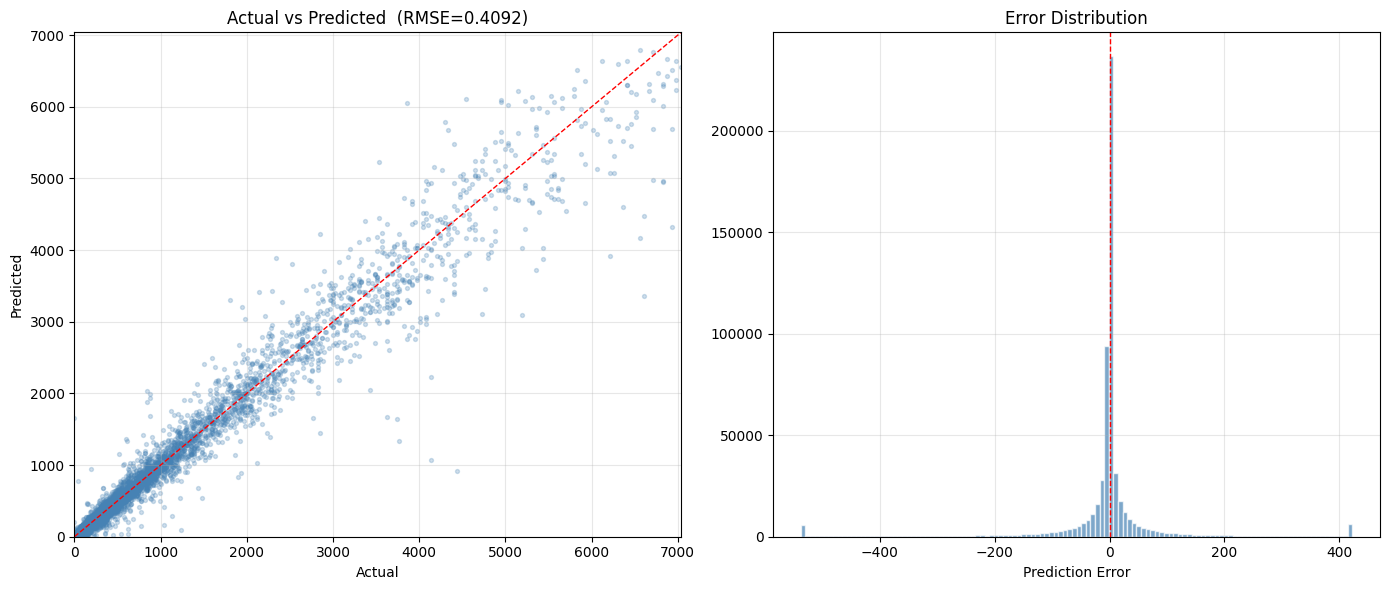

In [58]:
# Actual vs Predicted + Error Distribution
val_df = pd.DataFrame({
    'y_true': np.expm1(y_val.values),
    'y_pred': np.maximum(np.expm1(y_pred_lgb), 0)
})
val_df = val_df[
    (val_df['y_true'] <= val_df['y_true'].quantile(0.99)) &
    (val_df['y_pred'] <= val_df['y_pred'].quantile(0.99))
]
sample = val_df.sample(min(15000, len(val_df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
mx = max(sample['y_true'].max(), sample['y_pred'].max())
axes[0].scatter(sample['y_true'], sample['y_pred'], alpha=0.25, s=8, c='steelblue')
axes[0].plot([0, mx], [0, mx], 'r--', lw=1)
axes[0].set(xlabel='Actual', ylabel='Predicted',
            title=f'Actual vs Predicted  (RMSE={rmse_lgb:.4f})',
            xlim=(0, mx), ylim=(0, mx))
axes[0].grid(alpha=0.3)

errs = (val_df['y_pred'] - val_df['y_true'])
errs = errs.clip(errs.quantile(0.01), errs.quantile(0.99))
axes[1].hist(errs, bins=120, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', ls='--', lw=1)
axes[1].set(xlabel='Prediction Error', title='Error Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

Top 20 Most Important Features:


,Feature,Importance
0,rolling_std_7,5317
1,lag_1_sales_log,5235
2,day,4721
3,dayofyear,4457
4,rolling_mean_7,4363
5,dayofweek,4000
6,rolling_std_14,3860
7,lag_7_sales_log,3501
8,sf_std_sales,3260
9,rolling_std_30,3139


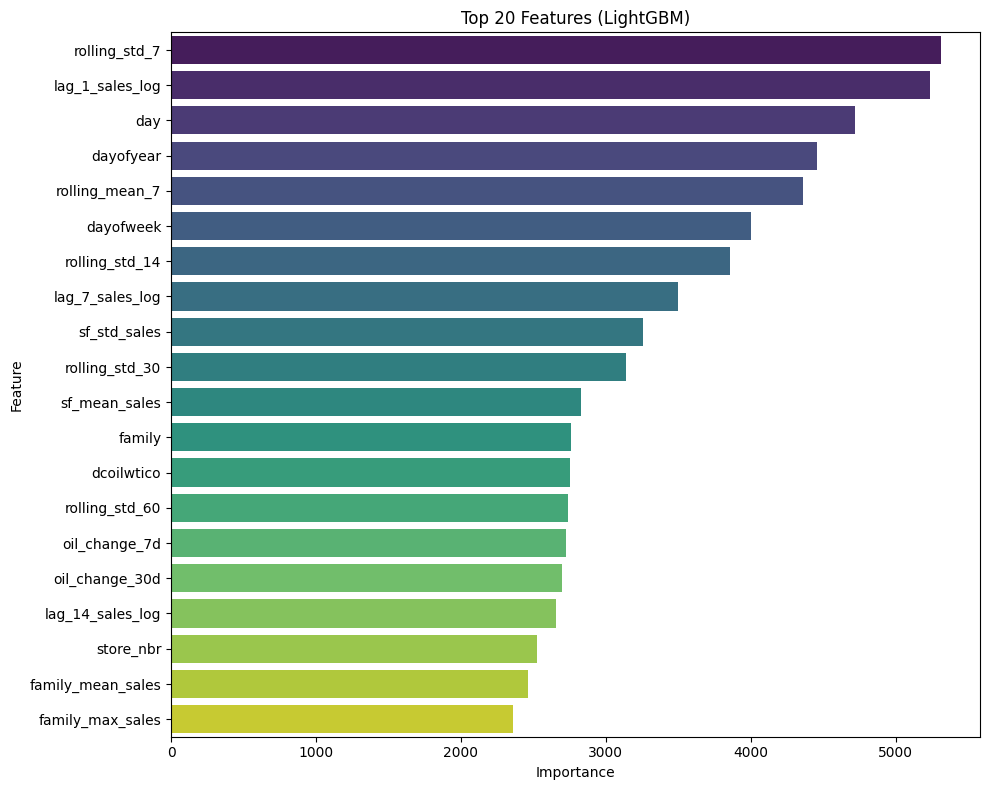

In [59]:
import seaborn as sns

# Feature Importance — Top 20
imp_df = pd.DataFrame({
    'Feature'   : features_for_model,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 Most Important Features:")
display(imp_df.head(20).reset_index(drop=True))

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=imp_df.head(20), palette='viridis')
plt.title('Top 20 Features (LightGBM)')
plt.tight_layout()
plt.show()

---
## 📤 Section 21 — Generate Submission File

In [61]:
X_test   = test_final[features_for_model].copy()
y_pred_test = np.maximum(np.expm1(lgb_model.predict(X_test)), 0)

submission = pd.DataFrame({
    'id'   : test['id'],
    'sales': y_pred_test
})
submission.to_csv('Final_submission.csv', index=False)

print("✅ Saved Final_submission.csv")
print(f"   Rows     : {len(submission):,}")
print(f"   Sales min: {submission['sales'].min():.2f}")
print(f"   Sales max: {submission['sales'].max():.2f}")
display(submission.head(10))

✅ Saved Final_submission.csv
   Rows     : 28,512
   Sales min: 0.00
   Sales max: 13215.09


,id,sales
0,3000888,3.574687
1,3000889,2.834479
2,3000890,2.808814
3,3000891,2.810842
4,3000892,0.987076
5,3000893,2.247702
6,3000894,2.532735
7,3000895,0.314435
8,3000896,0.346345
9,3000897,0.260992
